In [ ]:
import pypsa
n = pypsa.Network("tamil_nadu_2025_26.nc")

INFO:pypsa.network.io:Imported network 'Tamil Nadu FY 2025-26 single-node UC inputs' has buses, generators, loads, storage_units


Annual peak: 19,987.33 MW at 2025-07-11 16:00:00
Optimizing peak week: 2025-07-07 00:00:00 to 2025-07-13 23:00:00


In [5]:
n

PyPSA Network 'Tamil Nadu FY 2025-26 single-node UC inputs'
-----------------------------------------------------------
Components:
 - Bus: 1
 - Generator: 24
 - Load: 1
 - StorageUnit: 1
Snapshots: 168

C:\Users\b076218\AppData\Local\Temp\ipykernel_42516\390334114.py:37: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  axes[0].plot(demand.index, demand, color="black", linewidth=2, label="Demand")


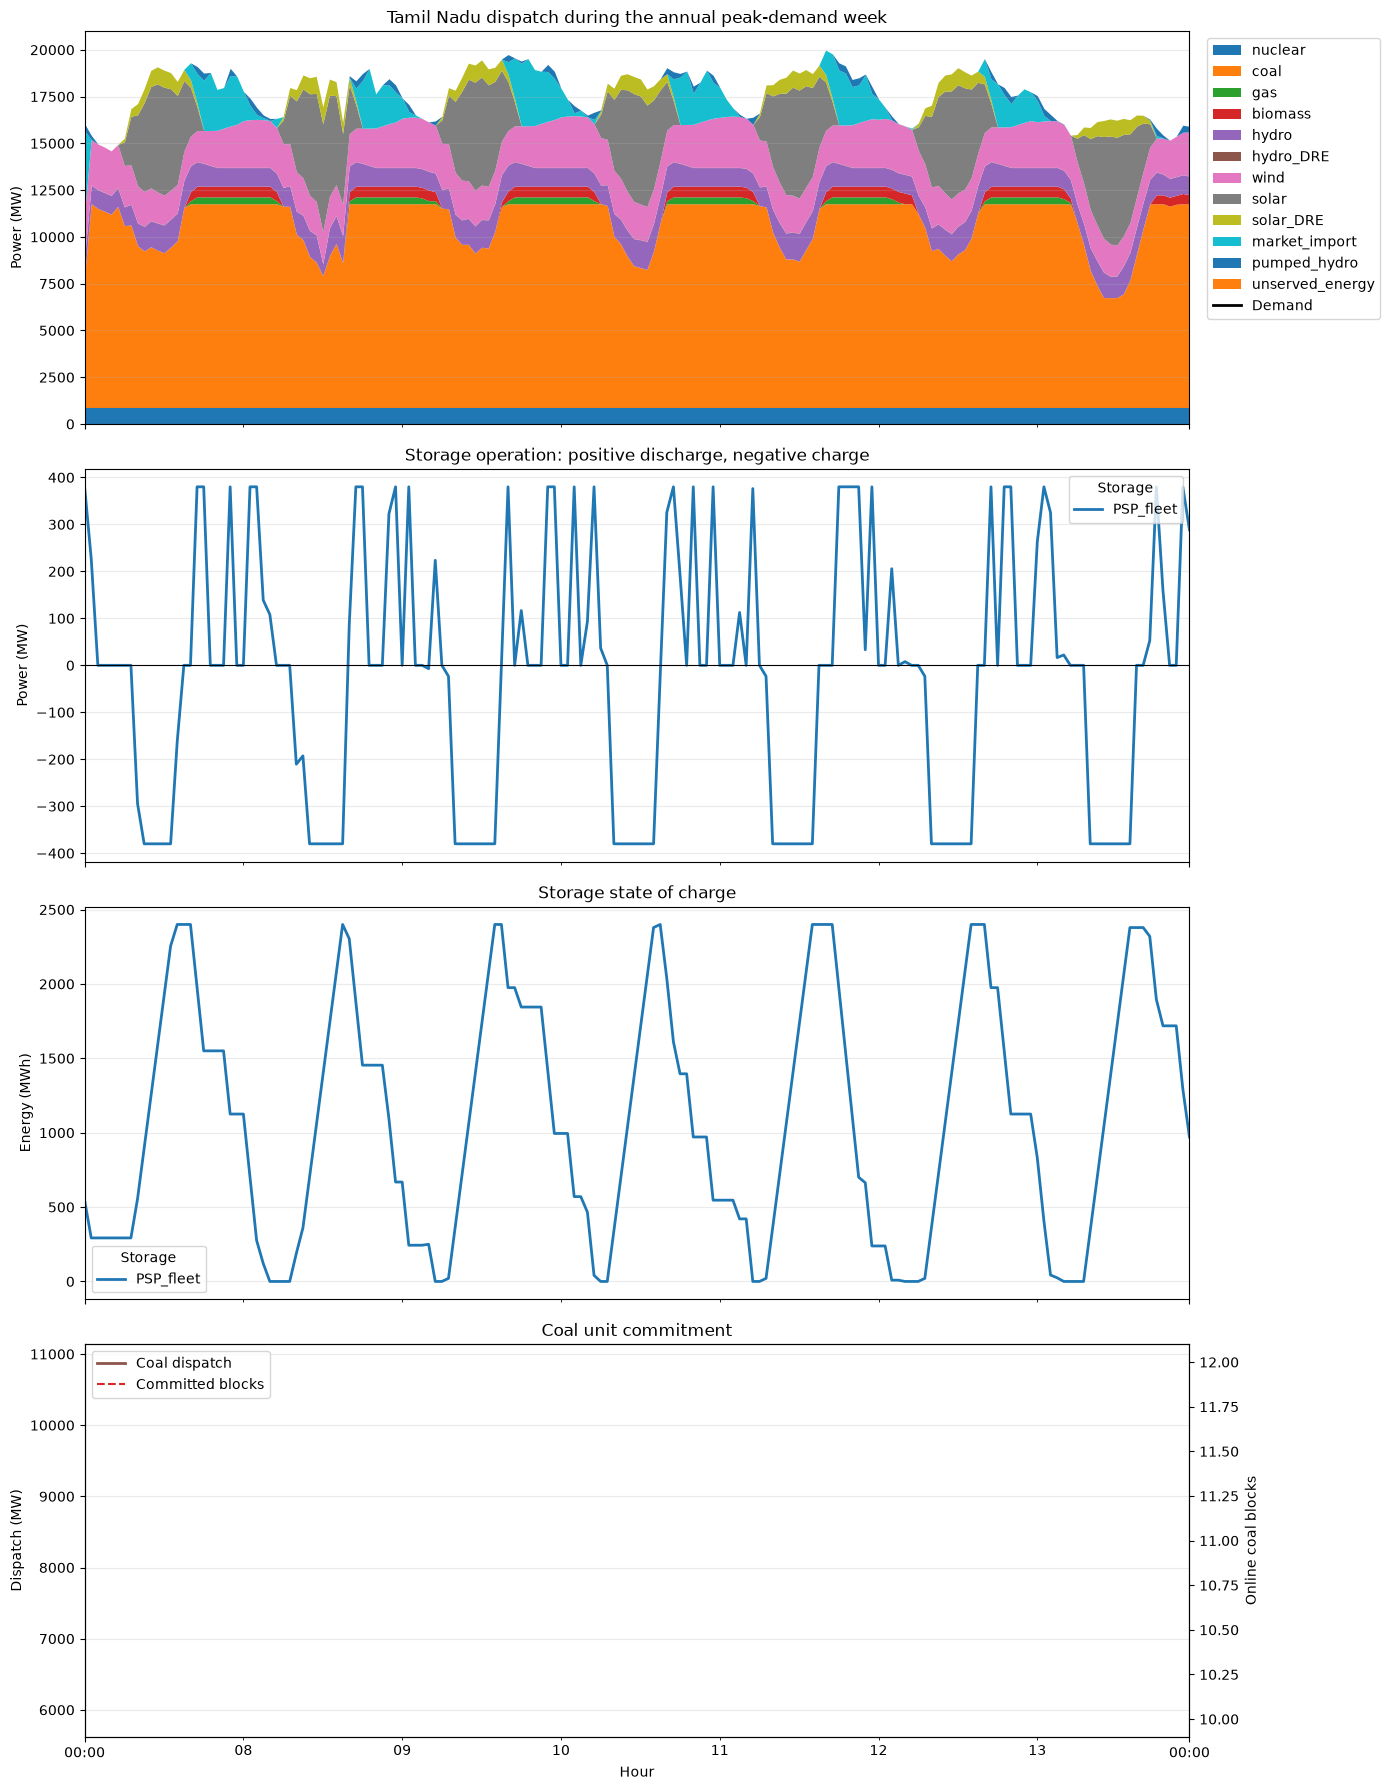

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

n

# Aggregate generator dispatch by carrier
generation = (
    n.generators_t.p
    .T.groupby(n.generators["carrier"])
    .sum().T
    .clip(lower=0)
)

# Storage: positive = discharge, negative = charge
storage_power = n.storage_units_t.p
storage_discharge = (
    storage_power.clip(lower=0)
    .T.groupby(n.storage_units["carrier"])
    .sum().T
)

supply = generation.add(storage_discharge, fill_value=0)
demand = n.loads_t.p_set.sum(axis=1)

carrier_order = [
    "nuclear", "coal", "gas", "biomass", "hydro", "hydro_DRE",
    "wind", "solar", "solar_DRE", "market_import",
    "battery", "pumped_hydro", "unserved_energy",
]
carrier_order = [c for c in carrier_order if c in supply.columns]
supply = supply[carrier_order]

fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)

# 1. Total system dispatch
supply.plot.area(ax=axes[0], stacked=True, linewidth=0)
axes[0].plot(demand.index, demand, color="black", linewidth=2, label="Demand")
axes[0].set_title("Tamil Nadu dispatch during the annual peak-demand week")
axes[0].set_ylabel("Power (MW)")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1))

# 2. Storage charge and discharge
storage_power.plot(ax=axes[1], linewidth=2)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Storage operation: positive discharge, negative charge")
axes[1].set_ylabel("Power (MW)")
axes[1].legend(title="Storage")

# 3. Storage state of charge
soc = n.storage_units_t.state_of_charge
soc.plot(ax=axes[2], linewidth=2)
axes[2].set_title("Storage state of charge")
axes[2].set_ylabel("Energy (MWh)")
axes[2].legend(title="Storage")

# 4. Coal dispatch and committed blocks
coal_units = n.generators.index[n.generators.carrier == "coal"]
coal_dispatch = n.generators_t.p[coal_units].sum(axis=1)
coal_online = n.generators_t.status[coal_units].sum(axis=1)

axes[3].plot(
    coal_dispatch.index, coal_dispatch,
    color="tab:brown", linewidth=2, label="Coal dispatch"
)
axes[3].set_title("Coal unit commitment")
axes[3].set_ylabel("Dispatch (MW)")

commitment_axis = axes[3].twinx()
commitment_axis.step(
    coal_online.index, coal_online,
    where="post", color="tab:red", linestyle="--",
    label="Committed blocks"
)
commitment_axis.set_ylabel("Online coal blocks")

lines1, labels1 = axes[3].get_legend_handles_labels()
lines2, labels2 = commitment_axis.get_legend_handles_labels()
axes[3].legend(lines1 + lines2, labels1 + labels2, loc="upper left")

axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[3].set_xlabel("Hour")
axes[3].grid(alpha=0.25)

for ax in axes[:3]:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()